*Part 1: Sections 1-4*

# 6a. Implementing Operational Gates

Fundamental concepts of Neural Networks are functioning as operational gates/nodes. These take in an input matrix and perform a function before forwarding them to the next gate/node.

Firstly, consider a multiplication operation as a gate: $f(x) = a \cdot x$

Declare $a$ input as a variable and $x$ as the input tensor for the model, meaning that $a$ will be optimized. The loss function is the difference between the output and target value (50).

Secondly, introduce a bias term: $f(x) = a \cdot x + b$

Declare $a$ and $b$ as variables and $x$ as the input tensor

Generally, for Neural Networks, emphasis is placed on the desired output rather than the intermediate variables.

In [1]:
import tensorflow as tf

'''Multipleication Operation as Gate'''
# Input data set to 5, training variable to be 10
a = tf.Variable(4.)
x_data = tf.keras.Input(shape=(1,))
x_val = 5.

# Create a lambda layer that computes the operation
multiply_layer = tf.keras.layers.Lambda(lambda x: tf.multiply(a, x))
outputs = multiply_layer(x_data)
model = tf.keras.Model(inputs=x_data, outputs=outputs, name='gate_1')

# Declare optimizing algorithm as stochastic gradient descent
optimizer = tf.keras.optimizers.SGD(0.01)

# Declare loss function as L2 distance
# Train: Continually feed the input value of 5 and backpropagating the loss to update model
print("Optimizing a Multiplication Gate Output to 50")
for i in range(10):
    # open a GradientTape
    with tf.GradientTape() as tape:
        # forward pass
        mult_output = model(x_val)
        
        # calculate loss
        loss_value = tf.square(tf.subtract(mult_output, 50))
        
    # get gradients of lss with reference to variable
    gradients = tape.gradient(loss_value, a)
    
    # update the variable of model
    optimizer.apply_gradients(zip([gradients], [a]))
    
    print(f"Step {i}: {a.numpy()} * {x_val} = {a.numpy() * x_val}")

The following Variables were used a Lambda layer's call (lambda), but
are not present in its tracked objects:
  <tf.Variable 'Variable:0' shape=() dtype=float32>
It is possible that this is intended behavior, but it is more likely
an omission. This is a strong indication that this layer should be
formulated as a subclassed Layer rather than a Lambda layer.
Optimizing a Multiplication Gate Output to 50
Step 0: 7.0 * 5.0 = 35.0
Step 1: 8.5 * 5.0 = 42.5
Step 2: 9.25 * 5.0 = 46.25
Step 3: 9.625 * 5.0 = 48.125
Step 4: 9.8125 * 5.0 = 49.0625
Step 5: 9.90625 * 5.0 = 49.53125
Step 6: 9.953125 * 5.0 = 49.765625
Step 7: 9.9765625 * 5.0 = 49.8828125
Step 8: 9.98828125 * 5.0 = 49.94140625
Step 9: 9.994140625 * 5.0 = 49.970703125


In [2]:
'''Multipleication Operation and Bias as Gate'''
x_data = tf.keras.Input(dtype=tf.float32, shape=(1,))
x_val = 5
a = tf.Variable(1., dtype=tf.float32)
b = tf.Variable(1., dtype=tf.float32)

multiply_layer = tf.keras.layers.Lambda(lambda x: tf.multiply(a, x))
add_layer = tf.keras.layers.Lambda(lambda x: tf.add(x, b))
mult_output = multiply_layer(x_data)
output = add_layer(mult_output)

model = tf.keras.Model(inputs=x_data, outputs=output, name='gate_2')

optimizer = tf.keras.optimizers.SGD(0.01)

print("Optmizing two Gate Operations Output to 50")
for i in range(10):
    with tf.GradientTape(persistent=True) as tape:
        out = model(x_val)
        
        loss = tf.square(tf.subtract(out, 50))
        
    gradients_a = tape.gradient(loss, a)
    gradients_b = tape.gradient(loss, b)
    
    optimizer.apply_gradients(zip([gradients_a, gradients_b], [a, b]))
    
    print(f"Step {i}: {a.numpy()} * {x_val} + {b.numpy()} = {a.numpy() * x_val + b.numpy()}")

The following Variables were used a Lambda layer's call (lambda_1), but
are not present in its tracked objects:
  <tf.Variable 'Variable:0' shape=() dtype=float32>
It is possible that this is intended behavior, but it is more likely
an omission. This is a strong indication that this layer should be
formulated as a subclassed Layer rather than a Lambda layer.
The following Variables were used a Lambda layer's call (lambda_2), but
are not present in its tracked objects:
  <tf.Variable 'Variable:0' shape=() dtype=float32>
It is possible that this is intended behavior, but it is more likely
an omission. This is a strong indication that this layer should be
formulated as a subclassed Layer rather than a Lambda layer.
Optmizing two Gate Operations Output to 50
Step 0: 5.400000095367432 * 5 + 1.8799999952316284 = 28.880000472068787
Step 1: 7.51200008392334 * 5 + 2.3024001121520996 = 39.8624005317688
Step 2: 8.52575969696045 * 5 + 2.5051522254943848 = 45.13395071029663
Step 3: 9.01236438751220

__Summary__

Tensorflow keeps track of model operations and adjusts the variables using backpropofation, to meet the intended output with respect to the optimization algorithm and output of the loss function.

Operational gates can be expanded with more inputs, just have to state which are variables and which are data.

# 6b. Working with gates and activation functions

Link operational gates and run output through activation functions. Introduce some common activation functions.

__Sigmoid__

$$
sigmoid(x) = \sigma(x) = \frac{1}{1+e^x}
$$

__ReLU__

$$
ReLU(x) = max(0, x)
$$

Create 2 one-layer neural networks with same structure, but 1 will feed through the Sigmoid function and the other ReLU. Loss will be L2 distance from 0.75. Randomly pull batch data and optimize output towards 0.75

In [17]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
tf.random.set_seed(5)
np.random.seed(42)

# Declare variables
BATCH_SIZE = 50

x = np.random.normal(2, 0.1, 500)
x_data = tf.keras.Input(shape=(1,))
a1 = tf.Variable(tf.random.normal(shape=[1,1], seed=5))
b1 = tf.Variable(tf.random.uniform(shape=[1,1], seed=5))
a2 = tf.Variable(tf.random.normal(shape=[1,1], seed=5))
b2 = tf.Variable(tf.random.uniform(shape=[1,1], seed=5))

# Declare 2 models
class MyCustomGateSigmoid(tf.keras.layers.Layer):
    def __init__(self, units, a1, b1):
        super(MyCustomGateSigmoid, self).__init__()
        self.units = units
        self.a1 = a1
        self.b1 = b1
    
    def call(self, inputs):
        return tf.math.sigmoid(inputs * self.a1 + self.b1)

custom_sigmoid_gate = MyCustomGateSigmoid(units=1, a1=a1, b1=b1)
output_sigmoid = custom_sigmoid_gate(x_data)
model_sigmoid = tf.keras.Model(inputs=x_data, outputs=output_sigmoid, name='gate_sigmoid')

class MyCustomGateRelu(tf.keras.layers.Layer):
    def __init__(self, units, a2, b2):
        super(MyCustomGateRelu, self).__init__()
        self.units = units
        self.a2 = a2
        self.b2 = b2
    
    def call(self, inputs):
        return tf.nn.relu(inputs * self.a2 + self.b2)

custom_relu_gate = MyCustomGateRelu(units=1, a2=a2, b2=b2)
output_relu = custom_relu_gate(x_data)
model_relu = tf.keras.Model(inputs=x_data, outputs=output_relu, name='gate_relu')

# Optimizer
optimizer = tf.keras.optimizers.SGD(0.01)

# Loop through and train both models
print("\n Optimizing Sigmoid AND Relu Output to 0.75")
loss_vec_sigmoid = []
loss_vec_relu = []
activation_sigmoid = []
activation_relu = []

for i in range(500):
    rand_indices = np.random.choice(len(x), size=BATCH_SIZE)
    x_vals = np.transpose([x[rand_indices]])

    with tf.GradientTape(persistent=True) as tape:
        output_sigmoid = model_sigmoid(x_vals)
        output_relu = model_relu(x_vals)

        loss_sigmoid = tf.reduce_mean(tf.square(tf.subtract(output_sigmoid, 0.75)))
        loss_vec_sigmoid.append(loss_sigmoid)
        loss_relu = tf.reduce_mean(tf.square(tf.subtract(output_relu, 0.75)))
        loss_vec_relu.append(loss_relu)
        
    gradients_a1 = tape.gradient(loss_sigmoid, custom_sigmoid_gate.a1)
    gradients_b1 = tape.gradient(loss_sigmoid, custom_sigmoid_gate.b1)

    gradients_a2 = tape.gradient(loss_relu, custom_relu_gate.a2)
    gradients_b2 = tape.gradient(loss_relu, custom_relu_gate.b2)

    # update variables
    optimizer.apply_gradients(zip([gradients_a1, gradients_b1], [custom_sigmoid_gate.a1, custom_sigmoid_gate.b1]))
    optimizer.apply_gradients(zip([gradients_a2, gradients_b2], [custom_relu_gate.a2, custom_relu_gate.b2]))
    
    output_sigmoid = model_sigmoid(x_vals)
    output_relu = model_relu(x_vals)
    
    activation_relu.append(np.mean(output_sigmoid))
    activation_relu.append(np.mean(output_relu))

    if i % 50 == 0:
        print(f"sigmoid = {str(np.mean(output_sigmoid))} | relu = {str(np.mean(output_relu))}") 



 Optimizing Sigmoid AND Relu Output to 0.75
sigmoid = 0.053502914 | relu = 0.41717994
sigmoid = 0.06592578 | relu = 0.74954367
sigmoid = 0.07885072 | relu = 0.7502562
sigmoid = 0.10079063 | relu = 0.75001615
sigmoid = 0.1306658 | relu = 0.74857485
sigmoid = 0.18301615 | relu = 0.7482997
sigmoid = 0.26148278 | relu = 0.7496901
sigmoid = 0.36430508 | relu = 0.75106066
sigmoid = 0.46104226 | relu = 0.74935675
sigmoid = 0.5375251 | relu = 0.7483227


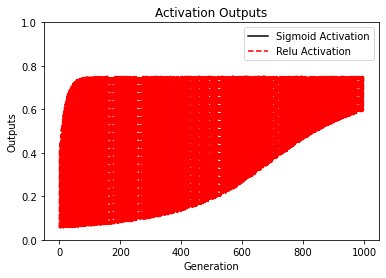

In [21]:
# Plot of Outputs
plt.plot(activation_sigmoid, 'k-', label='Sigmoid Activation') 
plt.plot(activation_relu, 'r--', label='Relu Activation') 
plt.ylim([0, 1.0]) 
plt.title('Activation Outputs') 
plt.xlabel('Generation') 
plt.ylabel('Outputs') 
plt.legend(loc='upper right') 
plt.show() 

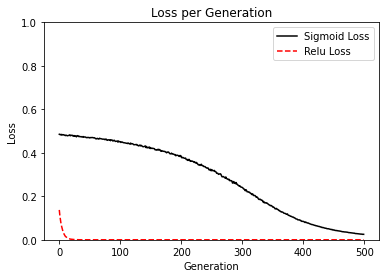

In [22]:
# Plot of loss per generation 
plt.plot(loss_vec_sigmoid, 'k-', label='Sigmoid Loss')
plt.plot(loss_vec_relu, 'r--', label='Relu Loss')
plt.ylim([0, 1.0])
plt.title('Loss per Generation')
plt.xlabel('Generation')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()

__Results__

Second figure shows that ReLU loss bottoms out much faster than Sigmoid. This is because of the form of the ReLU activation function, it returns the value 0 much more than Sigmoid function. This sparsity results in a speeding up of convergence, but at a loss of controlled gradients.

Sigmoid function has well-controlled gradients, meaning extreme values are not risked, which can potentially point the model in the wrong direction.

Tradeoff here is between speed of convergence and potential extreme values that can lead the model in the wrong direction.

__Summary__

Generally activations can fall into 2 categories:

1. Sigmoid-shaped: arctan, hypertangent, heaviside step, ...
2. ReLU-shaped: softplys, leaky ReLU, ...

Most of the addvantages and disadvantanges of each category holds true for the other activation functions that fall under the same category. But note that the __activation function has a big impact on the convergence__ of neural networks

# 4c. Implementing a one-layer Neural Network

Create a one-layer neural network that operates on the `Iris` dataset.

Regression problem, use MSE as loss function.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn import datasets

# Load Iris data
iris = datasets.load_iris()
x_vals = np.array([x[0:3] for x in iris.data])
y_vals = np.array([x[3] for x in iris.data])

# Set seed
SEED = 3
BATCH_SIZE = 50
x_data = tf.keras.Input(shape=(3,), dtype=tf.float32)
tf.random.set_seed(SEED)
np.random.seed(SEED)

# 80-20 train test split
train_indices = np.random.choice(len(x_vals), round(len(x_vals)*0.8), replace=False)
test_indices = np.array(list(set(range(len(x_vals))) - set(train_indices)))
x_val_train = x_vals[train_indices]
y_val_train = y_vals[train_indices]
x_val_test = x_vals[test_indices]
y_val_test = y_vals[test_indices]

def normalize_cols(m):
    col_max = m.max(axis=0)
    col_min = m.min(axis=0)
    return (m-col_min) / (col_max-col_min)

# Replace empty values with normalized value of column
x_vals_train = np.nan_to_num(normalize_cols(x_val_train))
x_vals_test = np.nan_to_num(normalize_cols(x_val_test))

In [2]:
# Creating the model
hidden_layer_nodes = 5
a1 = tf.Variable(tf.random.normal(shape=[3, hidden_layer_nodes], seed=SEED))
b1 = tf.Variable(tf.random.normal(shape=[hidden_layer_nodes], seed=SEED))
a2 = tf.Variable(tf.random.normal(shape=[hidden_layer_nodes, 1], seed=SEED))
b2 = tf.Variable(tf.random.normal(shape=[1], seed=SEED))

# Initialize the layers
hidden_layer = tf.keras.layers.Lambda(lambda x: tf.nn.relu(tf.add(tf.matmul(x, a1), b1)))
final_layer = tf.keras.layers.Lambda(lambda x: tf.nn.relu(tf.add(tf.matmul(x, a2), b2)))

hidden_output = hidden_layer(x_data)
final_output = final_layer(hidden_output)

model = tf.keras.Model(inputs=x_data, outputs=final_output, name='1layer_neural_network')

# Declare optimizer
optimizer = tf.keras.optimizers.SGD(0.005)

# Train model
# loss vectors for storage and plotting later
loss_vec = []
test_loss = []
for i in range(500):
    rand_index = np.random.choice(len(x_vals_train), size=BATCH_SIZE)
    rand_x = x_val_train[rand_index]
    rand_y = np.transpose([y_val_train[rand_index]])
    
    with tf.GradientTape(persistent=True) as tape:
        output = model(rand_x)
        loss = tf.reduce_mean(tf.square(rand_y - output))
        loss_vec.append(np.sqrt(loss))
    
    gradients_a1 = tape.gradient(loss, a1)
    gradients_b1 = tape.gradient(loss, b1)
    gradients_a2 = tape.gradient(loss, a2)
    gradients_b2 = tape.gradient(loss, b2)
    
    optimizer.apply_gradients(zip([gradients_a1, gradients_b1, gradients_a2, gradients_b2], [a1, b1, a2, b2]))
    
    output_test = model(x_vals_test)
    
    loss_test = tf.reduce_mean(tf.square(np.transpose([y_val_test]) - output_test))
    test_loss.append(np.sqrt(loss_test))
    
    if (i+1) % 50 == 0: 
        print(f"Generation: {str(i+1)} | Training Loss = {str(np.sqrt(loss))} | Testing Loss = {str(np.sqrt(loss_test))}")


The following Variables were used a Lambda layer's call (lambda), but
are not present in its tracked objects:
  <tf.Variable 'Variable:0' shape=(3, 5) dtype=float32>
  <tf.Variable 'Variable:0' shape=(5,) dtype=float32>
It is possible that this is intended behavior, but it is more likely
an omission. This is a strong indication that this layer should be
formulated as a subclassed Layer rather than a Lambda layer.
The following Variables were used a Lambda layer's call (lambda_1), but
are not present in its tracked objects:
  <tf.Variable 'Variable:0' shape=(5, 1) dtype=float32>
  <tf.Variable 'Variable:0' shape=(1,) dtype=float32>
It is possible that this is intended behavior, but it is more likely
an omission. This is a strong indication that this layer should be
formulated as a subclassed Layer rather than a Lambda layer.
Generation: 50 | Training Loss = 0.79349995 | Testing Loss = 1.2230062
Generation: 100 | Training Loss = 0.5220681 | Testing Loss = 1.2174914
Generation: 150 | Trai

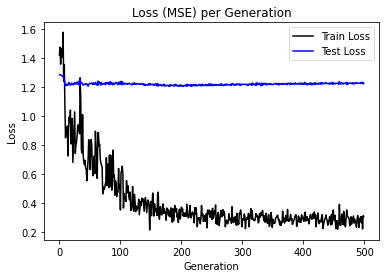

In [3]:
plt.plot(loss_vec, 'k-', label='Train Loss')
plt.plot(test_loss, 'b-', label='Test Loss')
plt.title('Loss (MSE) per Generation')
plt.xlabel('Generation')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()

__Results__

Train set not as smooth compared to the test set because batch size is a lot smaller and the model is being trained on the training set compared to the test set.